In [11]:
# Instalar librerías
%pip install pandas sqlalchemy pymysql matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import pandas as pd
from sqlalchemy import create_engine

# Variables de conexión
DB_USER = "alumno_user"
DB_PASS = "alumno_password_99"
DB_HOST = "localhost"  
DB_PORT = "3306"
DB_NAME = "sistema_alumnos"

# Crear el motor de conexión
engine = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
print("Motor de conexión creado exitosamente.")

Motor de conexión creado exitosamente.


In [ ]:
# Descarga de las tablas necesarias
df_inscripciones = pd.read_sql_query("SELECT * FROM inscripciones", engine)
df_programas = pd.read_sql_query("SELECT * FROM programas", engine)
df_historial = pd.read_sql_query("SELECT * FROM historial_inscripciones", engine)
df_alumnos = pd.read_sql_query("SELECT * FROM alumnos", engine)

print(f"Datos cargados en memoria. Inscripciones encontradas: {len(df_inscripciones)}")

Datos cargados en memoria. Inscripciones encontradas: 465


In [ ]:
# Distribución de estatus por programa utilizando
df_merge_prog = pd.merge(df_inscripciones, df_programas, left_on='programa_id', right_on='id')

distribucion_estatus = pd.pivot_table(
    df_merge_prog, 
    index='nombre',
    columns='estatus_actual', 
    aggfunc='size', 
    fill_value=0
)
distribucion_estatus

estatus_actual,Activo,Baja de empresa,Baja del programa,Egresado,Inscrito,Reingreso,Suspendido
nombre,,,,,,,
Bachillerato Ejecutivo,2,2,2,11,0,1,0
Bachillerato General,0,13,2,2,0,0,0
Lic. Administración,22,2,11,1,0,1,1
Lic. Contaduría,3,2,0,0,2,2,5
Lic. Logística,11,24,84,46,4,6,4
Lic. Mercadotecnia,1,0,8,3,0,0,4
Lic. Negocios,19,33,50,7,7,4,8
Maestría en Dirección,1,5,11,3,0,0,2
Maestría en Educación,4,1,0,5,0,1,7


In [ ]:
# Evolución mensual de movimientos
df_historial['created_at'] = pd.to_datetime(df_historial['created_at'])
df_historial['mes_año'] = df_historial['created_at'].dt.to_period('M')

# Agrupar altas e inscripciones iniciales vs bajas
evolucion_mensual = df_historial.groupby(['mes_año', 'estatus_nuevo']).size().unstack(fill_value=0)

# Simplificar columnas de bajas combinadas
bajas_totales = evolucion_mensual.get('Baja de empresa', 0) + evolucion_mensual.get('Baja del programa', 0)
activos_altas = evolucion_mensual.get('Inscrito', 0) + evolucion_mensual.get('Activo', 0)

df_evolucion = pd.DataFrame({
    'Altas/Activos': activos_altas,
    'Bajas Totales': bajas_totales
}).fillna(0)

df_evolucion

,Altas/Activos,Bajas Totales
mes_año,,
2013-08,2,2
2013-12,1,1
2014-02,3,3
2014-03,1,1
2014-04,1,1
...,...,...
2025-12,3,0
2026-02,6,0
2026-04,8,0


In [ ]:
# Tasa de alumnos activos por programa
total_historico = df_merge_prog.groupby('nombre').size()
total_activos = df_merge_prog[df_merge_prog['estatus_actual'].isin(['Activo', 'Inscrito'])].groupby('nombre').size()

tasa_activos = (total_activos / total_historico * 100).round(2).to_frame(name='tasa_activos_porcentaje')
tasa_activos['total_inscritos_historicos'] = total_historico
tasa_activos.fillna(0)

,tasa_activos_porcentaje,total_inscritos_historicos
nombre,,
Bachillerato Ejecutivo,11.11,18
Bachillerato General,0.00,17
Lic. Administración,57.89,38
Lic. Contaduría,35.71,14
Lic. Logística,8.38,179
Lic. Mercadotecnia,6.25,16
Lic. Negocios,20.31,128
Maestría en Dirección,4.55,22
Maestría en Educación,22.22,18


In [ ]:
# Análisis de texto para motivos de baja frecuentes
df_bajas_historial = df_historial[df_historial['estatus_nuevo'].isin(['Baja de empresa', 'Baja del programa'])]

motivos_frecuentes = df_bajas_historial['motivo'].value_counts().to_frame(name='frecuencia')
print("--- Motivos de baja más comunes detectados en el sistema ---")
motivos_frecuentes.head(5)

--- Motivos de baja más comunes detectados en el sistema ---


,frecuencia
motivo,
Cambio de estado solicitado. Estatus final: Baja del programa,178
Cambio de estado solicitado. Estatus final: Baja de empresa,84


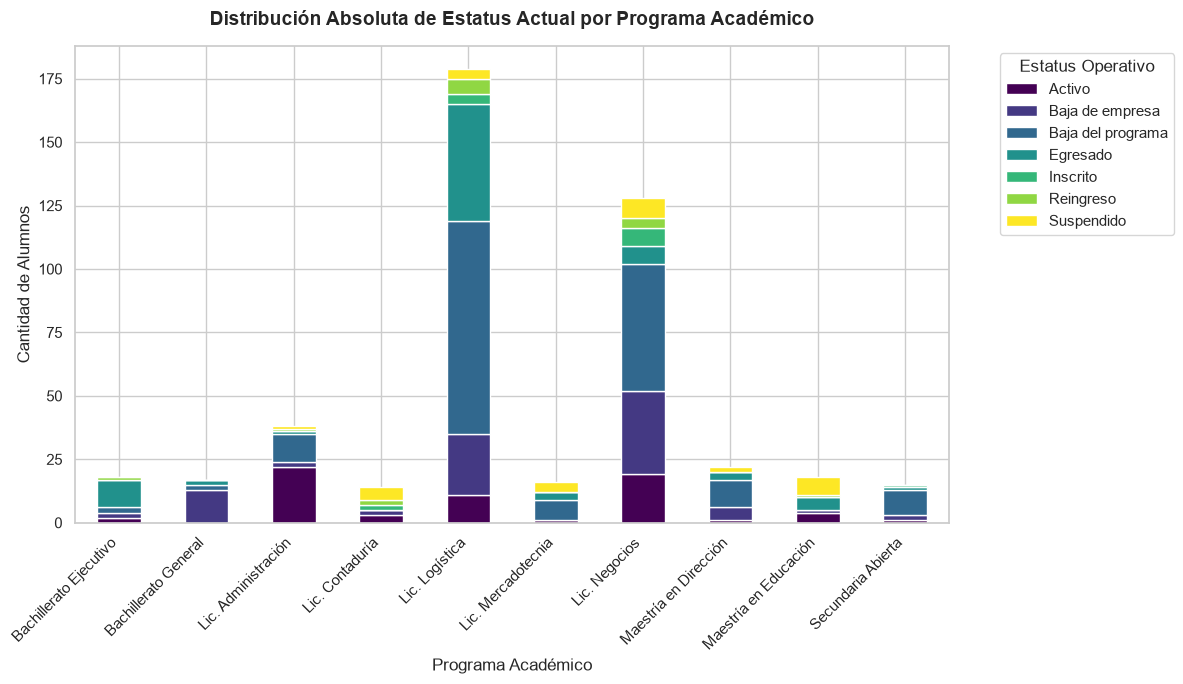

In [ ]:
# Gráfica de barras apiladas
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

ax = distribucion_estatus.plot(kind='bar', stacked=True, figsize=(12, 7), cmap='viridis')

plt.title('Distribución Absoluta de Estatus Actual por Programa Académico', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Programa Académico', fontsize=12)
plt.ylabel('Cantidad de Alumnos', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Estatus Operativo', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

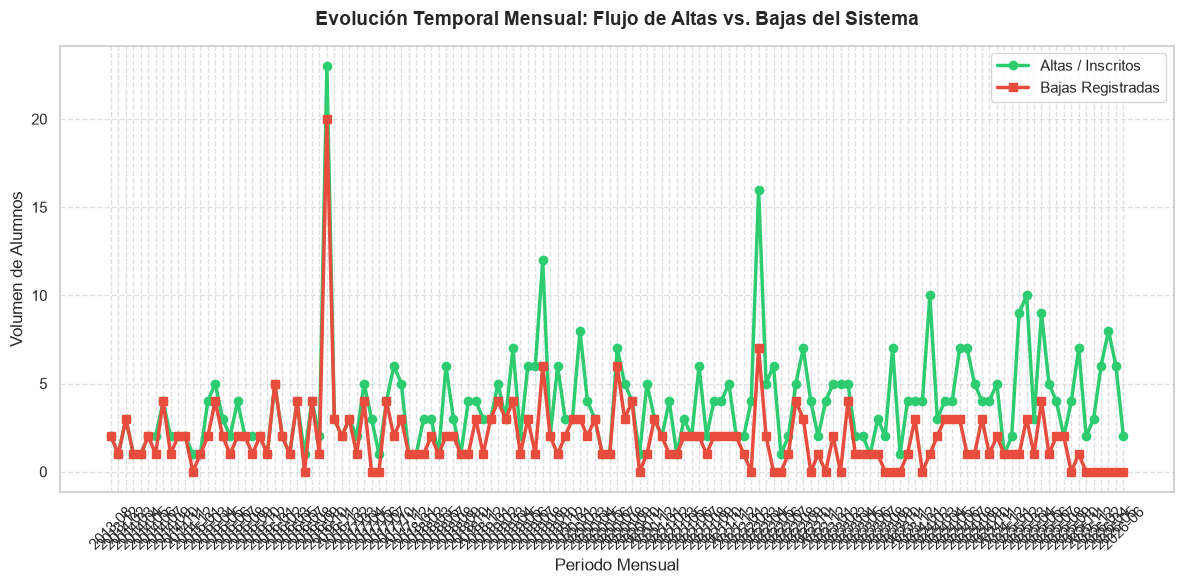

In [ ]:
# Gráfica de línea 
plt.figure(figsize=(12, 6))

# Convertimos el índice de Periodos de Pandas a string para graficación lineal limpia
ejex_fechas = df_evolucion.index.astype(str)

plt.plot(ejex_fechas, df_evolucion['Altas/Activos'], marker='o', linewidth=2.5, color='#2ecc71', label='Altas / Inscritos')
plt.plot(ejex_fechas, df_evolucion['Bajas Totales'], marker='s', linewidth=2.5, color='#e74c3c', label='Bajas Registradas')

plt.title('Evolución Temporal Mensual: Flujo de Altas vs. Bajas del Sistema', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Periodo Mensual', fontsize=12)
plt.ylabel('Volumen de Alumnos', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()